In [1]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from geopy import distance
import statsmodels.api as sm
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Statistical Exploration of OPTN Data

In Lab 5, we explored the OPTN organ donation data. In one of the steps, we modeled the relationship of various features with the transplant success rate. Let's dive deeper here.

In [2]:
# read and process data
optn_df = pd.read_sql("SELECT * FROM optn", sqlite3.connect("optn_reduced.sqlite3"))
optn_df["deceased_donor"] = optn_df["deceased_donor"].astype(bool)
optn_df["succeeded_1_year"] = optn_df["succeeded_1_year"].astype(bool)


def transplant_distance_miles(row):
    return distance.distance(
        (row["donor_lat"], row["donor_lon"]),
        (row["transplant_lat"], row["transplant_lon"]),
    ).miles


optn_df["distance_miles"] = optn_df.apply(transplant_distance_miles, axis=1)

# split the data by organ
liver_df = optn_df[optn_df["organ"] == "liver"]
kidney_df = optn_df[optn_df["organ"] == "kidney"]
optn_df.head()

,preservation_hours,recipient_age,donor_age,organ,deceased_donor,succeeded_1_year,donor_lat,donor_lon,transplant_lat,transplant_lon,transplant_year,distance_miles
0,6.1,30-59,60-99,liver,True,True,43.15,-75.18,42.27,-71.76,2017-2024,184.370227
1,5.0,60-99,0-29,liver,True,True,41.25,-75.88,39.96,-75.20,2007-2016,95.925424
2,5.7,30-59,30-59,liver,True,False,38.03,-84.51,35.13,-90.00,2017-2024,364.858865
3,7.5,30-59,60-99,liver,True,True,37.66,-121.02,37.76,-122.46,2007-2016,79.198770
4,5.3,30-59,0-29,liver,True,False,39.70,-104.84,40.66,-111.89,2017-2024,378.821725


## Cold Ischemic Time

In our initial exploration, one of the most influential features that determines liver transplant success is the Cold Ischemic Time (CIT). That is the time that the liver is on ice. Let's further assess this feature.

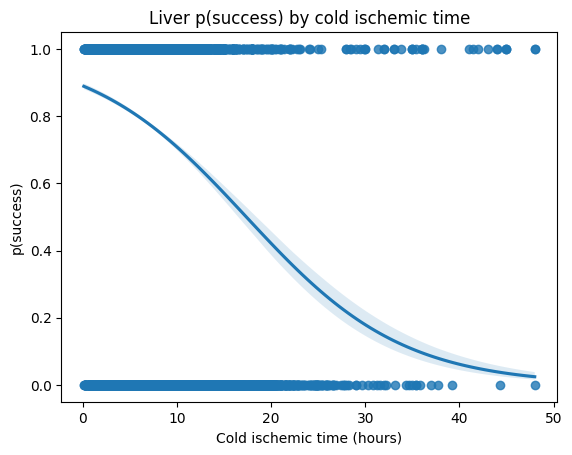

In [3]:
success_df = liver_df[(liver_df["preservation_hours"] > 0)].sample(
    frac=0.2, random_state=42
)

ax = sns.regplot(
    data=success_df,
    x=success_df["preservation_hours"],
    y=success_df["succeeded_1_year"],
    logistic=True,
)
ax.set_title("Liver p(success) by cold ischemic time")
ax.set_xlabel("Cold ischemic time (hours)")
ax.set_ylabel("p(success)")
plt.show()

The fitted logistic regression curve is attempting to relate CIT to the chance of transplant success. Based on the plot, it seems that as the liver stays longer on ice, the chance of success decreases.

Let's poke around with this result. Reading the plot, we see that right around 20 hours, there is a decrease in the number of data points, and simultaneously, the blue shadow (i.e., the confidence interval) becomes wider. It seems that the model is not as confident about the chance of success as CIT gets longer.

To investigate the model, we first assess whether the relationship actually follows an S-shaped trend. One very crude way to do this is to bin the data by CIT and use the proportion of successful transplants in each bin to estimate the probability of success. In the following plot, we will overlay the estimated probabilities in each bin (left y-axis) and the number of data points in each bin (right y-axis).

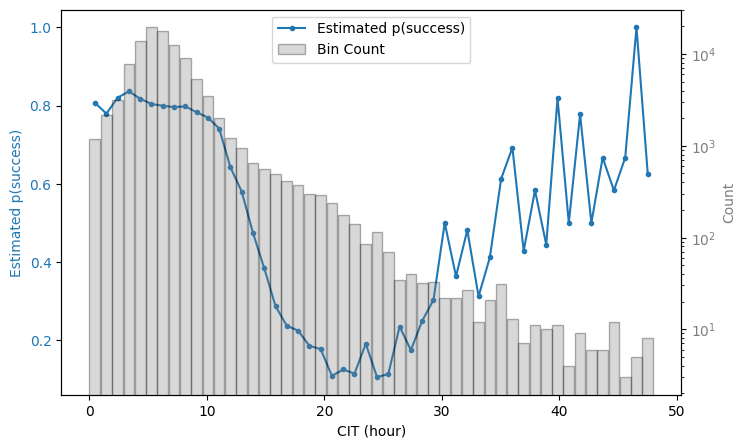

In [4]:
bin_count = 50  # change this to explore

# make a slice of liver_df
bin_df = liver_df.copy()

# Use pd.cut to compute bins
bins, bin_edges = pd.cut(bin_df["preservation_hours"], bins=bin_count, retbins=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# estimate the probability of success
prob_est = bin_df.groupby(bins, observed=False)["succeeded_1_year"].mean()
prob_est.index = bin_centers  # replace Interval index with numeric centers

# histogram counts for plotting
hist_counts, _ = np.histogram(bin_df["preservation_hours"], bins=bin_edges)

fig, ax1 = plt.subplots(figsize=(8, 5))

# left y-axis: probability of success
color_prob = "tab:blue"
(prob_line,) = ax1.plot(
    bin_centers,
    prob_est,
    color=color_prob,
    marker="o",
    label="Estimated p(success)",
    markersize=3,
)
ax1.set_xlabel("CIT (hour)")
ax1.set_ylabel("Estimated p(success)", color=color_prob)
ax1.tick_params(axis="y", labelcolor=color_prob)

# right y-axis: histogram counts
color_hist = "tab:gray"
ax2 = ax1.twinx()
hist_bars = ax2.bar(
    bin_centers,
    hist_counts,
    width=(bin_edges[1] - bin_edges[0] - 0.1),
    alpha=0.3,
    color=color_hist,
    label="Bin Count",
    align="center",
    edgecolor="black",
)
ax2.set_yscale("log")
ax2.set_ylabel("Count", color=color_hist)
ax2.tick_params(axis="y", labelcolor=color_hist)

# combine the legends of the two plots
artists = [prob_line] + ([hist_bars] if hist_counts.any() else [])
labels = [art.get_label() for art in artists if not art.get_label().startswith("_")]
artists_filtered = [art for art in artists if not art.get_label().startswith("_")]
ax1.legend(artists_filtered, labels, loc="upper center")

plt.show()

In the well-populated region of the plot — say CIT under 20 hours — the binned estimates trace out the same gentle downward trend as the fitted logistic curve. That's reassuring: the summary curve from earlier is a reasonable description of how empirical success rates trend with CIT, at least where we have enough data to say anything at all.

In the sparse region, things get noisy. The estimated probabilities fluctuate and can even appear to rise for some choices of bin size; only about 0.5% of the liver data report CIT longer than 24 hours, so we shouldn't read those bins as a signal. The fitted logistic curve is still confidently low out there because logistic regression assumes a particular S-shape and extrapolates it across the full range of x. That's not a flaw in the model — it's just what fitting a curve does. The takeaway is that we should trust the curve where the data are dense and stay agnostic about what happens at the extreme end of CIT.

So what is the CIT story here? We should be confident in saying that when you have a CIT for, say, less than a day, a longer CIT is associated with lowered transplant success. For CIT longer than a day, we need to study the particular instance or look into other features to reason about success rate. Let's then revisit the initial logistic regression plot. We now know the result for CIT > 25 is noisy and only accounts for 0.5% of the data, yet in the plot, those data occupy half the area. Let's exclude those data and produce a more realistic visualization.

**Note**: Throwing out the outlier data does not mean they are not useful. In this case, it would actually be quite important to study those data points and reason about their formation. Feel free to explore! 

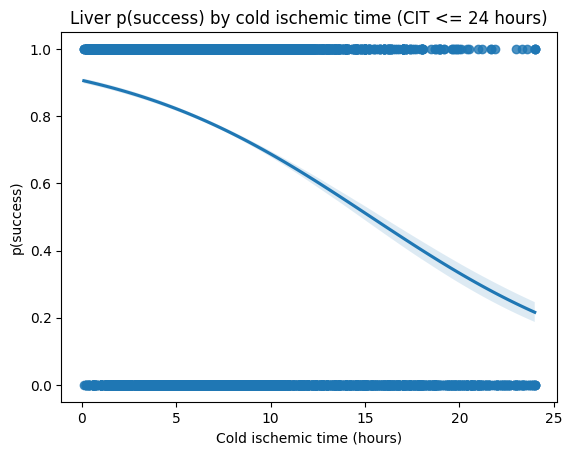

In [5]:
success_df = liver_df[
    (liver_df["preservation_hours"] > 0) & (liver_df["preservation_hours"] <= 24)
].sample(frac=0.2, random_state=42)

ax = sns.regplot(
    data=success_df,
    x=success_df["preservation_hours"],
    y=success_df["succeeded_1_year"],
    logistic=True,
)
ax.set_title("Liver p(success) by cold ischemic time (CIT <= 24 hours)")
ax.set_xlabel("Cold ischemic time (hours)")
ax.set_ylabel("p(success)")
plt.show()

## Building a Predictive Model

Next, let's try combining more features in our dataset and assess whether we can use them to *predict* whether the transplant will be successful. Informed by our discussion above, we will only consider liver transplants with CIT <= 24 hours.

In [6]:
liver_df_reduced = liver_df[liver_df["preservation_hours"] <= 24]

# separate the features and the target variable
X = liver_df_reduced.drop(columns=["succeeded_1_year", "organ"])
y = liver_df_reduced["succeeded_1_year"]

In order to assess the performance of our predictions, we will split our dataset into a training set that we use to train our model, and a held-out test set that we evaluate the predictions on.

In [7]:
# train-test split with 20% held out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# reset index
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


From now on, we will only use the training set to make our modeling decisions, and will only use the test set to assess performance at the end of each model's construction.

Next, let's construct a **baseline model** that we can compare our models to. A baseline model is usually the simplest model one can construct. In this case, we have a natural choice: in our dataset, we have a majority of successful liver transplants.

In [8]:
y_train.mean()

0.7797129048198724

There is a significant **class imbalance** issue in our dataset. What this means is that if a model *predicts "successful" for all transplants*, it will have an accuracy of 78%, so there's not much room to improve in raw accuracy. We will use this simple model as a baseline.

In [9]:
# baseline model predictions
baseline_pred_train = np.ones_like(y_train)
baseline_pred_test = np.ones_like(y_test)

# baseline model accuracy
baseline_acc_train = (baseline_pred_train == y_train).mean()
baseline_acc_test = (baseline_pred_test == y_test).mean()
print(f"Baseline train accuracy: {baseline_acc_train:.4f}")
print(f"Baseline test accuracy: {baseline_acc_test:.4f}")

Baseline train accuracy: 0.7797
Baseline test accuracy: 0.7797


Another metric we will compute for each model is the [cross-entropy loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) (also called **log loss**). This metric assesses performance not on the predicted labels (i.e., successful or unsuccessful), but on the predicted probability of success.

In [10]:
# baselien predicted probabilities
baseline_probs_train = y_train.mean() * np.ones_like(y_train)
baseline_probs_test = y_test.mean() * np.ones_like(y_test)

# baseline log loss
baseline_logloss_train = log_loss(y_train, baseline_probs_train)
baseline_logloss_test = log_loss(y_test, baseline_probs_test)
print(f"Baseline train log loss: {baseline_logloss_train:.4f}")
print(f"Baseline test log loss: {baseline_logloss_test:.4f}")

Baseline train log loss: 0.5273
Baseline test log loss: 0.5272


We write a function to compute these metrics given predictions.

In [11]:
def compute_metrics(y_true, probs_pred, threshold=0.5):
    # convert probabilities to predictions using a threshold of 0.5
    preds = (probs_pred > threshold).astype(int)
    # compute accuracy
    acc = (preds == y_true).mean()
    # compute log loss
    logloss = log_loss(y_true, probs_pred)
    return acc, logloss

Another baseline we can have is the logistic regression model we built in the last section where we only used a single feature (CIT).

In [12]:
# train simple logistic model
simple_logistic_model = sm.Logit(y_train, X_train["preservation_hours"])
simple_logistic_result = simple_logistic_model.fit(maxiter=500, disp=False)

# get predicted probabilities
simple_logistic_probs_train = simple_logistic_result.predict(
    X_train["preservation_hours"]
)
simple_logistic_probs_test = simple_logistic_result.predict(
    X_test["preservation_hours"]
)

simple_logistic_acc_train, simple_logistic_logloss_train = compute_metrics(
    y_train, simple_logistic_probs_train
)
simple_logistic_acc_test, simple_logistic_logloss_test = compute_metrics(
    y_test, simple_logistic_probs_test
)
print(f"Simple logistic train accuracy: {simple_logistic_acc_train:.4f}")
print(f"Simple logistic test accuracy: {simple_logistic_acc_test:.4f}")
print(f"Simple logistic train log loss: {simple_logistic_logloss_train:.4f}")
print(f"Simple logistic test log loss: {simple_logistic_logloss_test:.4f}")


Simple logistic train accuracy: 0.7797
Simple logistic test accuracy: 0.7795
Simple logistic train log loss: 0.5949
Simple logistic test log loss: 0.5916


The second baseline actually gives a higher log loss than the first (constant predictor) baseline.

To build our full model, we need to process some features first. In particular, the `*_age` and `transplant_year` columns are strings that represent categories; a statistical model can only take in numerical values as input. We use a technique called [**one-hot encoding**](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/) to make these columns numeric. One-hot encoding takes every distinct value of a column and makes each value a new column that has `True` if a data point has that value, and `False` otherwise.

In [ ]:
# one-hot encode the categorical variables
X_train_encoded = pd.get_dummies(
    X_train,
    columns=[
        "recipient_age",
        "donor_age",
        "transplant_year",
    ],
    drop_first=True,
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=[
        "recipient_age",
        "donor_age",
        "transplant_year",
    ],
    drop_first=True,
)

X_train_encoded.head()

,preservation_hours,deceased_donor,donor_lat,donor_lon,transplant_lat,transplant_lon,distance_miles,recipient_age_30-59,recipient_age_60-99,donor_age_30-59,donor_age_60-99,transplant_year_1997-2006,transplant_year_2007-2016,transplant_year_2017-2024
0,4.6,True,36.06,-114.93,33.46,-112.05,242.800358,True,False,True,False,False,True,False
1,6.6,True,29.73,-95.68,32.79,-96.77,220.459480,False,True,True,False,False,False,True
2,6.8,True,39.48,-119.73,37.41,-122.17,194.673872,True,False,True,False,False,False,True
3,8.6,True,43.12,-77.62,40.76,-73.96,249.151325,True,False,False,False,False,True,False
4,5.0,True,33.51,-86.80,38.62,-90.25,401.698097,False,True,True,False,False,False,True


A key step in building a model is deciding which variables to include. With many candidate features, we want some way to flag the ones that aren't pulling their weight. A common technique for this is [**lasso regression**](https://en.wikipedia.org/wiki/Lasso_(statistics)) (also called **L1 regularization**).

The mechanism: when we fit ordinary logistic regression, we pick the curve (or surface, if we have more than 1 feature), that best fits the data. Lasso adds an extra term to that optimization — a penalty on the sum of the amount of influence (i.e., coefficients) each feature has on the predicted probability. The effect is that every feature has to "earn its keep" in fit improvement to stay influential; features that aren't contributing much get pushed all the way to zero influence, and the feature effectively drops out of the model. Once we fit a lasso, we can rank features by how big their influence is — tiny ones are our candidates for dropping.

Some practical notes:

- For coefficient size to be a fair comparison across features, the features have to be on the same scale. So we put a **standardization** step in front of the lasso (`StandardScaler`), which rescales each column to have mean 0 and standard deviation 1. The `Pipeline` object just chains these two steps so they run together.
- We're switching from [`statsmodels`](https://www.statsmodels.org/stable/index.html) to [**`scikit-learn`**](https://scikit-learn.org/stable/) here because the former doesn't expose L1-regularized logistic regression as conveniently. We'll stay in sklearn for the random forest later too.
- We need to decide on how much penalty to apply. For convenience, we use an automatic procedure, `LogisticRegressionCV`, that determines a good penalty value via a procedure called [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).

Caveat: lasso is a quick automatic screen, not a definitive verdict. It can be sensitive to the random seed and, when two features are highly correlated, can essentially flip a coin about which one to keep. Useful as a starting point, not a final answer.

In [14]:
# Build a pipeline that first scales (required by lasso), then runs lasso with cross-validation
lasso_cv_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lasso_cv",
            LogisticRegressionCV(
                penalty="l1",
                solver="saga",
                max_iter=1000,
                cv=5,
                scoring="neg_log_loss",
                random_state=42,
                refit=True,
            ),
        ),
    ]
)

# Fit the pipeline to the one-hot encoded features and target variable
lasso_cv_pipe.fit(X_train_encoded, y_train)

# Get the absolute values of the coefficients from the best model (choose first row if multinomial)
lasso_coef_cv = abs(lasso_cv_pipe.named_steps["lasso_cv"].coef_.flatten())

# Print results in a dataframe, as before
pd.DataFrame({"|coef|": lasso_coef_cv}, index=X_train_encoded.columns).sort_values(
    "|coef|", ascending=False
)

,|coef|
transplant_year_2007-2016,0.705452
preservation_hours,0.489469
transplant_year_1997-2006,0.362295
transplant_year_2017-2024,0.259886
deceased_donor,0.143301
donor_age_60-99,0.140736
donor_age_30-59,0.098778
transplant_lon,0.056236
distance_miles,0.020316
donor_lat,0.012854


We will probably drop `transplant_lat` and `donor_lon`. Some age bins also have a small influence, but this could be due to poor binning choice rather than true lack of influence. We will need to return to the original, unbinned data to verify. For now, we will keep these features.

In [ ]:
cols_to_drop = ["transplant_lat", "donor_lon"]
X_train_reduced = X_train_encoded.drop(columns=cols_to_drop).astype(float)
X_test_reduced = X_test_encoded.drop(columns=cols_to_drop).astype(float)

Now let's fit a logistic regression model with these features.

In [16]:
# Standardize the features for use with statsmodels
X_full_model_train = pd.DataFrame(
    StandardScaler().fit_transform(X_train_reduced),
    columns=X_train_reduced.columns,
    index=X_train_reduced.index,  # ensure index is preserved
)
X_full_model_train = sm.add_constant(X_full_model_train)

X_full_model_test = pd.DataFrame(
    StandardScaler().fit_transform(X_test_reduced),
    columns=X_test_reduced.columns,
    index=X_test_reduced.index,  # ensure index is preserved
)
X_full_model_test = sm.add_constant(X_full_model_test)

# Fit the logistic regression using the standardized data
full_logistic_model = sm.Logit(y_train, X_full_model_train)
full_logistic_result = full_logistic_model.fit(maxiter=500, disp=False)

# make predictions
full_logistic_probs_train = full_logistic_result.predict(X_full_model_train)
full_logistic_probs_test = full_logistic_result.predict(X_full_model_test)

# compute metrics
full_logistic_acc_train, full_logistic_logloss_train = compute_metrics(
    y_train, full_logistic_probs_train
)
full_logistic_acc_test, full_logistic_logloss_test = compute_metrics(
    y_test, full_logistic_probs_test
)
print(f"Full logistic train accuracy: {full_logistic_acc_train:.4f}")
print(f"Full logistic test accuracy: {full_logistic_acc_test:.4f}")
print(f"Full logistic train log loss: {full_logistic_logloss_train:.4f}")
print(f"Full logistic test log loss: {full_logistic_logloss_test:.4f}")

Full logistic train accuracy: 0.8009
Full logistic test accuracy: 0.7991
Full logistic train log loss: 0.4879
Full logistic test log loss: 0.4892


The cross-entropy loss is lower than the baseline. Let's take a look at the model summary.

In [17]:
print(full_logistic_result.summary2())

                              Results: Logit
Model:                 Logit               Method:              MLE       
Dependent Variable:    succeeded_1_year    Pseudo R-squared:    0.075     
Date:                  2026-05-05 16:10    AIC:                 80983.3918
No. Observations:      82969               BIC:                 81104.6327
Df Model:              12                  Log-Likelihood:      -40479.   
Df Residuals:          82956               LL-Null:             -43747.   
Converged:             1.0000              LLR p-value:         0.0000    
No. Iterations:        6.0000              Scale:               1.0000    
--------------------------------------------------------------------------
                           Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
const                      1.3728   0.0092 149.9354 0.0000  1.3548  1.3907
preservation_hours        -0.4896   0.0091 -53.7456 0.0

The top part of the summary provides some diagnostic statistics. One metric to note is the [**Pseudo R-squared**](https://en.wikipedia.org/wiki/Pseudo-R-squared), which roughly indicates how much better the model does than the constant-model baseline. The value of 0.075 shows that the model is rather weak as a predictive model. The bottom part of the summary provides some insights into each feature's influence on the predicted probability.

### A more flexible model

It doesn't seem like logistic regression is a good model for our data. Logistic regression is a relatively simple *linear* model (here linear means something more complicated than just $y=x$, but it's in the same spirit). So let's do something more complicated. [**Random forest**](https://en.wikipedia.org/wiki/Random_forest) is a machine learning algorithm widely used in practice. It relies on these [*decision trees*](https://scikit-learn.org/stable/modules/tree.html) that can be viewed as pathways to split the data. Let's fit a random forest model over the data.

In [18]:
# make and fit rf model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_features=0.33,
    min_samples_leaf=5,
)
rf.fit(X_train_reduced, y_train)

# measure
rf_probs_train = rf.predict_proba(X_train_reduced)[:, 1]
rf_preds_train = (rf_probs_train > 0.5).astype(int)
rf_acc_train, rf_logloss_train = compute_metrics(y_train, rf_probs_train)
print(f"Random forest train accuracy: {rf_acc_train:.4f}")
print(f"Random forest train log loss: {rf_logloss_train:.4f}")

Random forest train accuracy: 0.8235
Random forest train log loss: 0.3517


We see the cross-entropy loss drop significantly. This may look like good news at first glance and might motivate you to use this model. However, we need to be careful about the analysis. With a more flexible model, a concerning phenomenon is [**overfitting**](https://en.wikipedia.org/wiki/Overfitting). This is when a model essentially memorizes the input-output pairs of the data instead of learning the true relationship between them. This can severely corrupt our analysis of which features are the most influential in determining transplant success.

A simple method to detect overfitting is to compute the performance metrics on the test set.

In [19]:
rf_probs_test = rf.predict_proba(X_test_reduced)[:, 1]
rf_preds_test = (rf_probs_test > 0.5).astype(int)
rf_acc_test, rf_logloss_test = compute_metrics(y_test, rf_probs_test)
print(f"Random forest test accuracy: {rf_acc_test:.4f}")
print(f"Random forest test log loss: {rf_logloss_test:.4f}")

Random forest test accuracy: 0.8006
Random forest test log loss: 0.4868


The train and test log loss differ by a lot, and the test log loss is very similar to the loss we have seen with logistic regression. It does seem like the model is overfitting, and we need to be cautious when drawing conclusions from the model. If we determine that the model is a good predictive model and would like to assess which features are influential in determining the chance of success, we can use a metric called [**feature importance**](https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html).

In [20]:
importances = rf.feature_importances_
feature_names = (
    X_train_reduced.columns
    if hasattr(X_train_reduced, "columns")
    else [f"feature_{i}" for i in range(len(importances))]
)
pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values(
    "importance", ascending=False
).reset_index(drop=True)

,feature,importance
0,preservation_hours,0.345962
1,distance_miles,0.200243
2,donor_lat,0.186277
3,transplant_lon,0.143031
4,transplant_year_2007-2016,0.040275
5,transplant_year_2017-2024,0.038500
6,donor_age_30-59,0.010385
7,transplant_year_1997-2006,0.010177
8,recipient_age_30-59,0.008232
9,donor_age_60-99,0.007516


## Conclusion

We have tried a bunch of models and it does not seem like we have improved much from the single-feature logistic regression model. Here are some potential reasons. 

- **Class imbalance**: About 78% of the data are successful transplants. This means that if the model simply outputs a probability of 1 for every data point, it would have been correct 78% of the time. This is a pretty high baseline to surpass.
- **Lack of more meaningful features**: The goal is to study transplant success, and all the features we have are about the transportation of the organ instead of the medical status of the patients. So it is very possible that few of the features we have are truly influential compared to medical features.